<a href="https://colab.research.google.com/github/shrutimalik123/patient-readmission-project/blob/main/Patient_Readmission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Predict patient readmission using a `RandomForestClassifier` after performing comprehensive exploratory data analysis, preprocessing features, and evaluating the model's performance with relevant metrics and feature importance analysis.

## Complete Exploratory Data Analysis (EDA)

### Subtask:
Perform comprehensive EDA including descriptive statistics, distribution analysis of numerical features, and frequency analysis of categorical features. Analyze relationships between features and the 'readmitted' target variable.


**Reasoning**:
The first step in EDA is to load the dataset, display its initial rows, and check for data types and missing values to get a foundational understanding of the data's structure and completeness.



# Task
Predict patient readmission using a `RandomForestClassifier` after performing comprehensive exploratory data analysis, preprocessing features, and evaluating the model's performance with relevant metrics and feature importance analysis.

## Analyze Descriptive Statistics

### Subtask:
Calculate and display descriptive statistics for all numerical features to understand their central tendency, dispersion, and shape. Additionally, analyze frequency counts and unique values for categorical features.


**Reasoning**:
Load the patient readmission dataset into a pandas DataFrame and display its first few rows to get an initial overview of the data structure and content.



In [1]:
import pandas as pd

df = pd.read_csv('/content/patient_readmission_dataset.csv')
print(df.head())

   patient_id  age  gender  length_of_stay  num_medications  num_procedures  \
0           1   69  Female               1                5               4   
1           2   32    Male               8                5               2   
2           3   89  Female               3                9               2   
3           4   78    Male               6               17               1   
4           5   38    Male               3               13               0   

  primary_diagnosis discharge_disposition  readmitted  
0      Hypertension        Against Advice           0  
1     Heart Failure       Skilled Nursing           1  
2         Pneumonia                 Rehab           0  
3         Pneumonia                  Home           1  
4     Heart Failure       Skilled Nursing           0  


**Reasoning**:
First, I will display the descriptive statistics for all numerical columns in the DataFrame using `df.describe()`. Then, I will identify categorical columns and iterate through them to calculate and print their value counts and number of unique values to understand their distribution and variety.



In [2]:
print("Descriptive statistics for numerical features:\n")
print(df.describe())

print("\nFrequency analysis for categorical features:\n")
for column in df.columns:
    if df[column].dtype == 'object' or df[column].nunique() < 10: # Assuming columns with less than 10 unique values are also categorical
        print(f"\nColumn: {column}")
        print(f"Unique values: {df[column].nunique()}")
        print(f"Value Counts:\n{df[column].value_counts()}")

Descriptive statistics for numerical features:

        patient_id          age  length_of_stay  num_medications  \
count  1000.000000  1000.000000     1000.000000       1000.00000   
mean    500.500000    52.881000        7.500000         10.13100   
std     288.819436    20.958915        4.024699          5.56784   
min       1.000000    18.000000        1.000000          1.00000   
25%     250.750000    34.750000        4.000000          5.00000   
50%     500.500000    52.500000        8.000000         10.00000   
75%     750.250000    71.000000       11.000000         15.00000   
max    1000.000000    89.000000       14.000000         19.00000   

       num_procedures   readmitted  
count     1000.000000  1000.000000  
mean         2.066000     0.244000  
std          1.393408     0.429708  
min          0.000000     0.000000  
25%          1.000000     0.000000  
50%          2.000000     0.000000  
75%          3.000000     0.000000  
max          4.000000     1.000000  

Frequ

## Visualize Feature Distributions

### Subtask:
Generate histograms or box plots for numerical features to visualize their distributions and identify potential outliers. Create bar plots or count plots for categorical features to visualize their frequencies and patterns. Ensure all plots have appropriate titles and labels.


**Reasoning**:
To visualize the distributions of numerical features, I will first import `matplotlib.pyplot` and `seaborn` for plotting. Then, I will iterate through the specified numerical columns and generate histograms for each, ensuring they have appropriate titles and labels for clarity.



Generating histograms for numerical features...


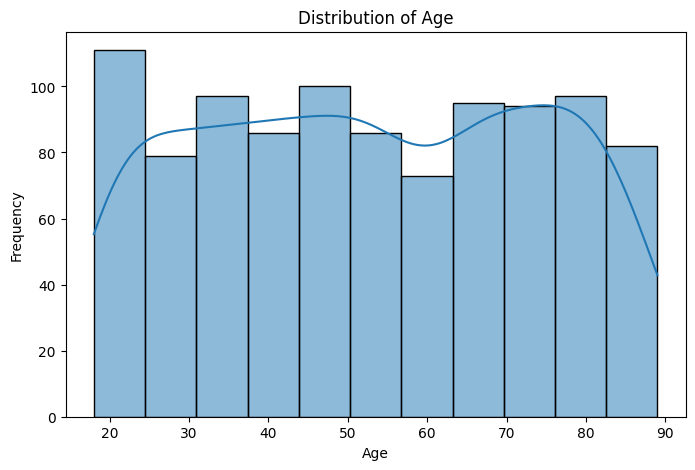

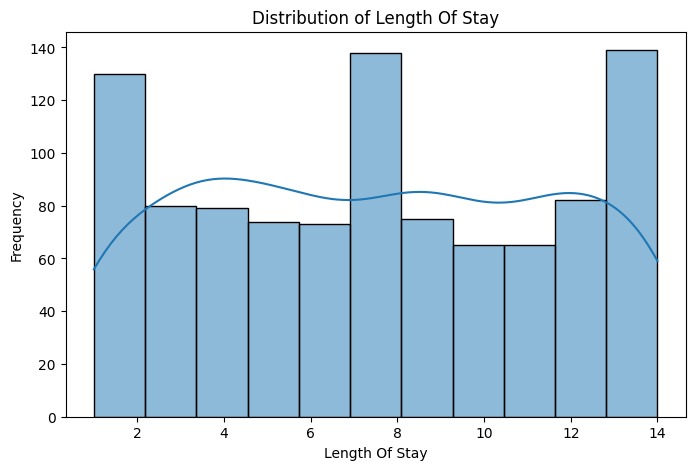

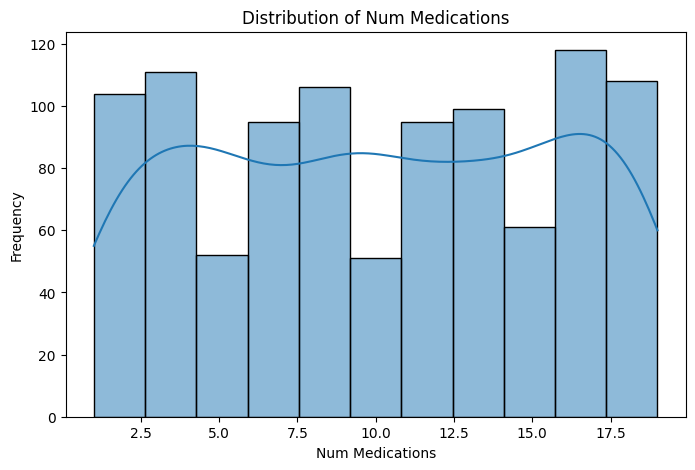

Generating count plots for categorical features...


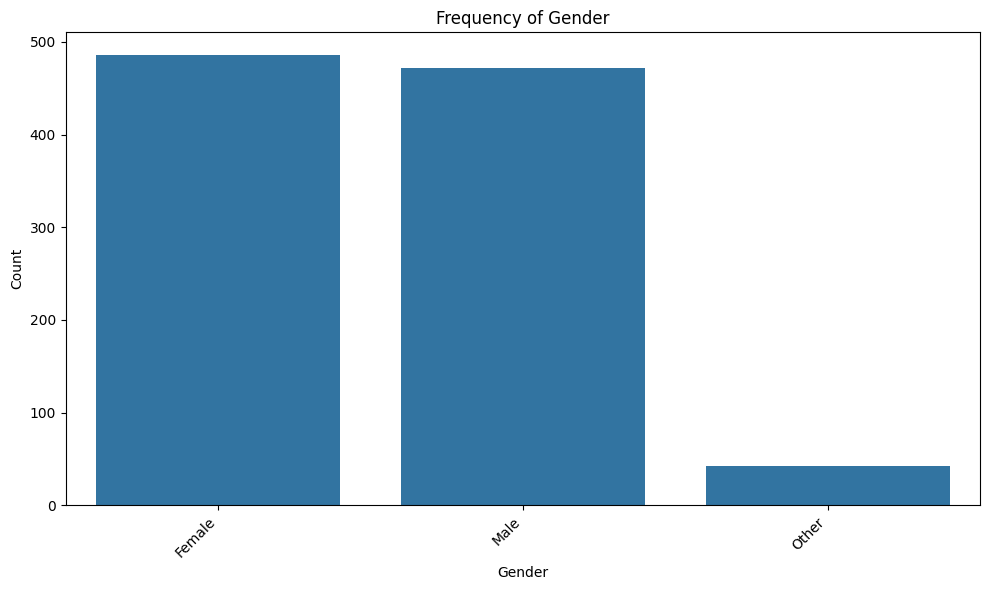

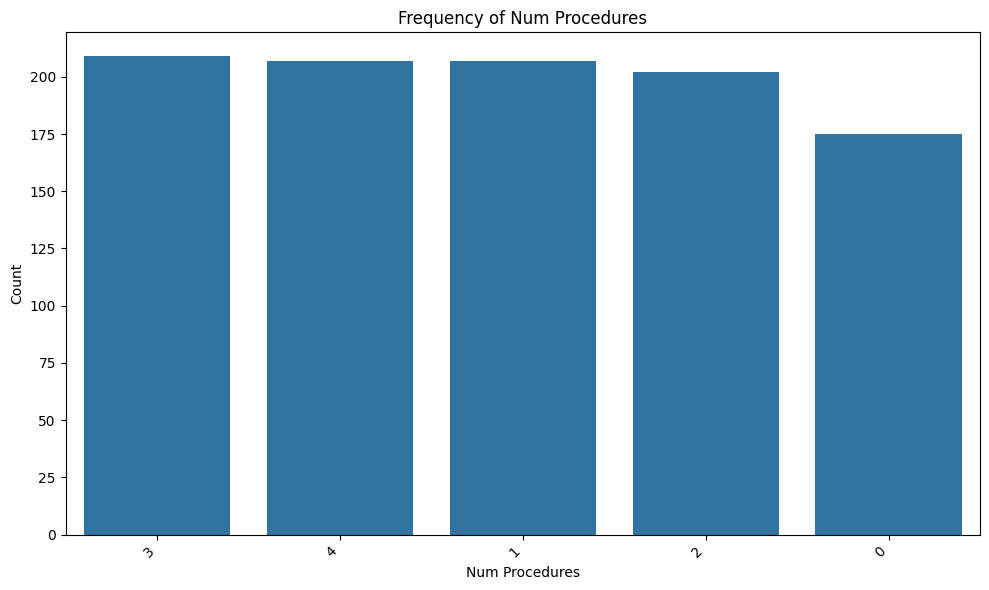

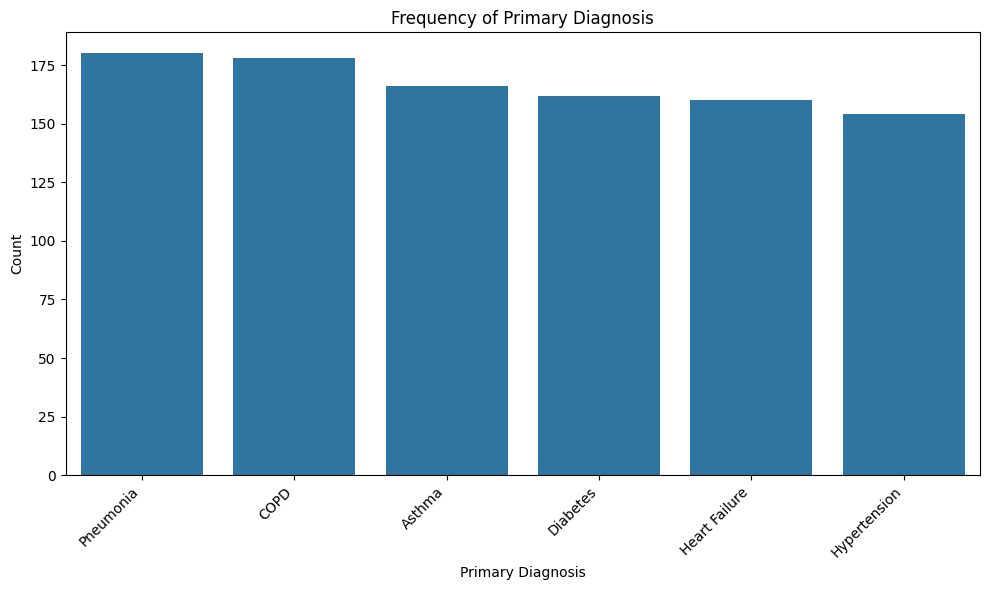

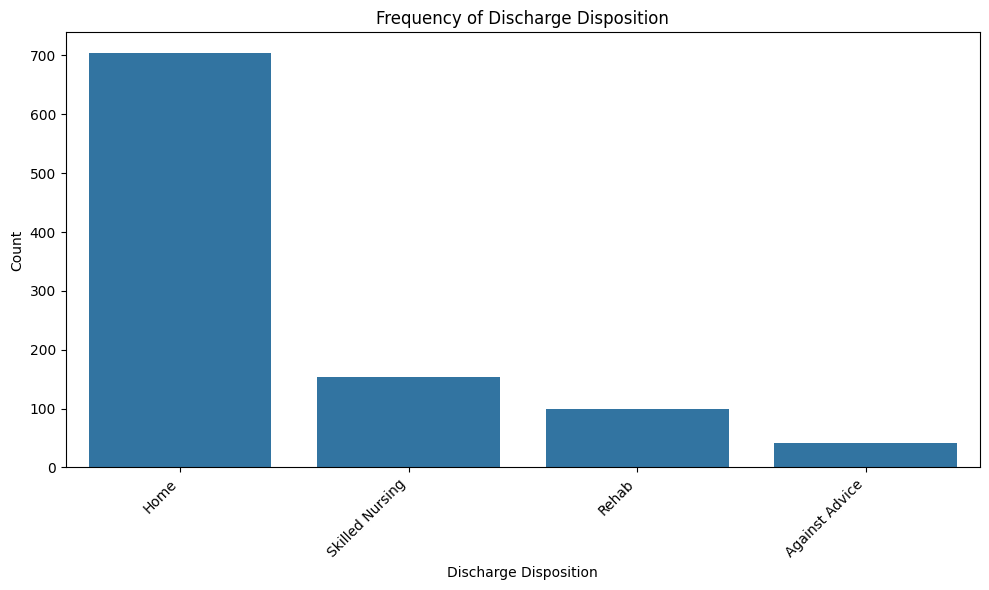

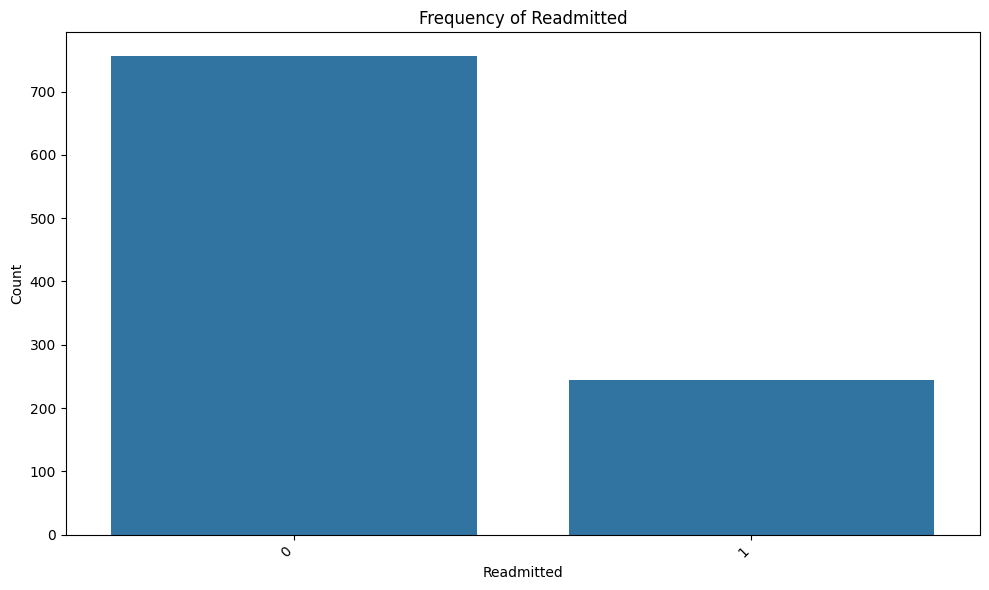

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical features
numerical_features = ['age', 'length_of_stay', 'num_medications']

# Create histograms for numerical features
print("Generating histograms for numerical features...")
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.show()

# Identify categorical features
categorical_features = ['gender', 'num_procedures', 'primary_diagnosis', 'discharge_disposition', 'readmitted']

# Create count plots for categorical features
print("Generating count plots for categorical features...")
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, order=df[feature].value_counts().index)
    plt.title(f'Frequency of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Analyze Feature-Target Relationships

### Subtask:
Explore the relationships between relevant features (both numerical and categorical) and the 'readmitted' target variable. Use visualizations such as box plots (for numerical vs. target) and stacked bar plots or cross-tabulations (for categorical vs. target) to identify potential predictors. Provide legends for all visualizations.


**Reasoning**:
To analyze the relationship between numerical features and the 'readmitted' target variable, I will generate box plots for each numerical feature, showing its distribution for both readmitted and not-readmitted patients.



Generating box plots for numerical features vs. readmitted status...


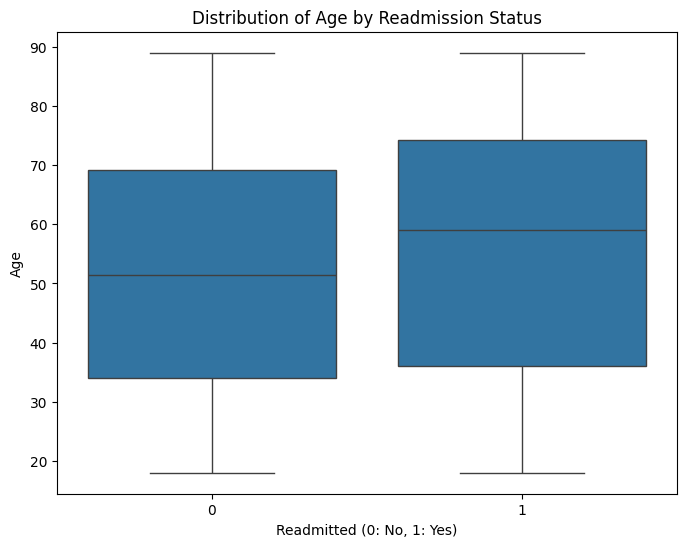

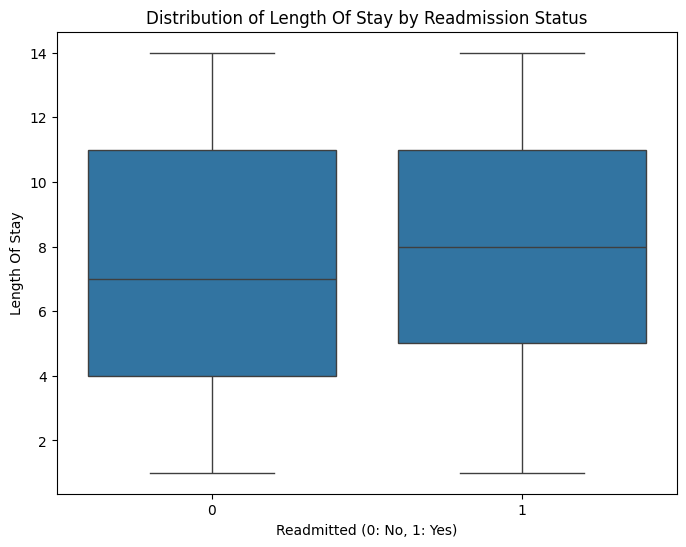

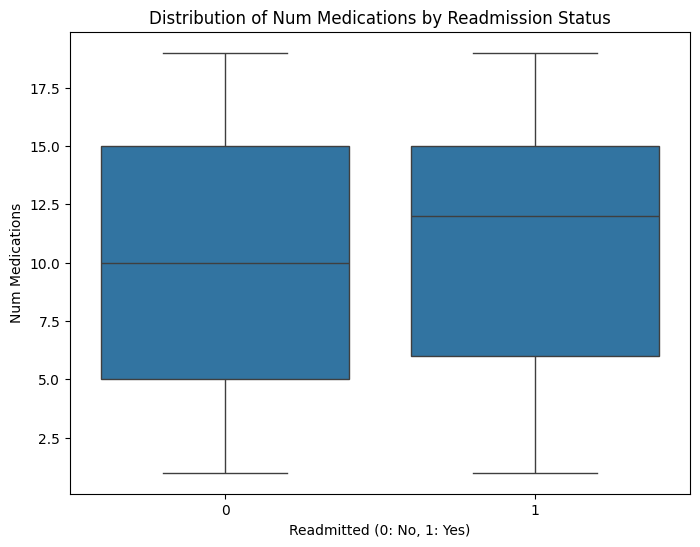

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features as identified in previous steps
numerical_features = ['age', 'length_of_stay', 'num_medications']

print("Generating box plots for numerical features vs. readmitted status...")
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='readmitted', y=feature, data=df)
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Readmission Status')
    plt.xlabel('Readmitted (0: No, 1: Yes)')
    plt.ylabel(feature.replace("_", " ").title())
    plt.show()

**Reasoning**:
To analyze the relationship between categorical features and the 'readmitted' target variable, I will generate stacked bar plots (or count plots with hue) for each categorical feature, showing the distribution of readmission status within each category.



Generating count plots for categorical features vs. readmitted status...


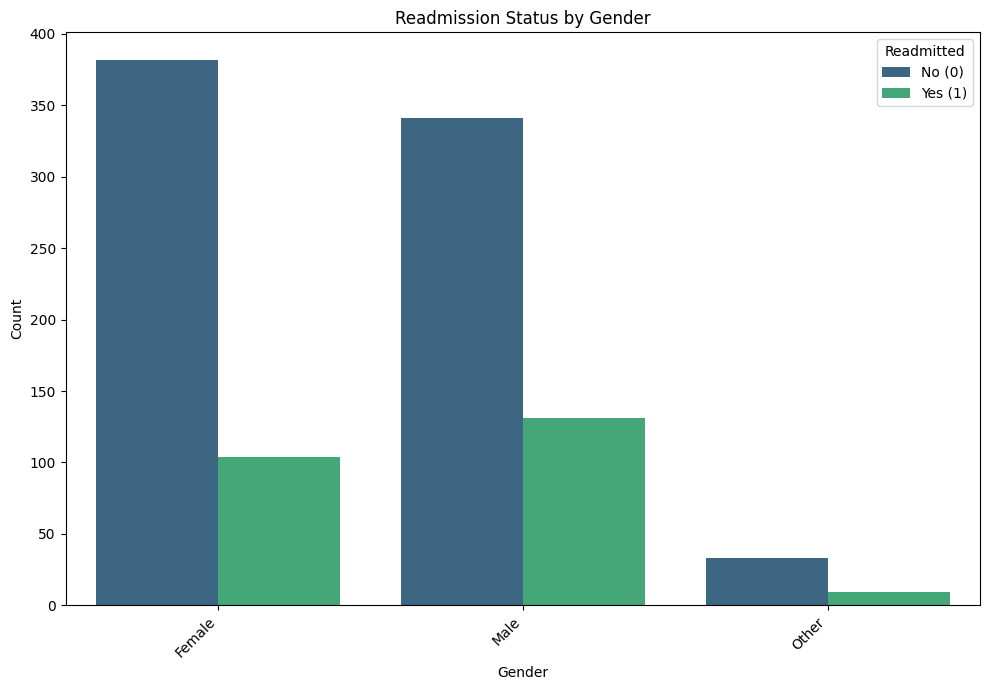

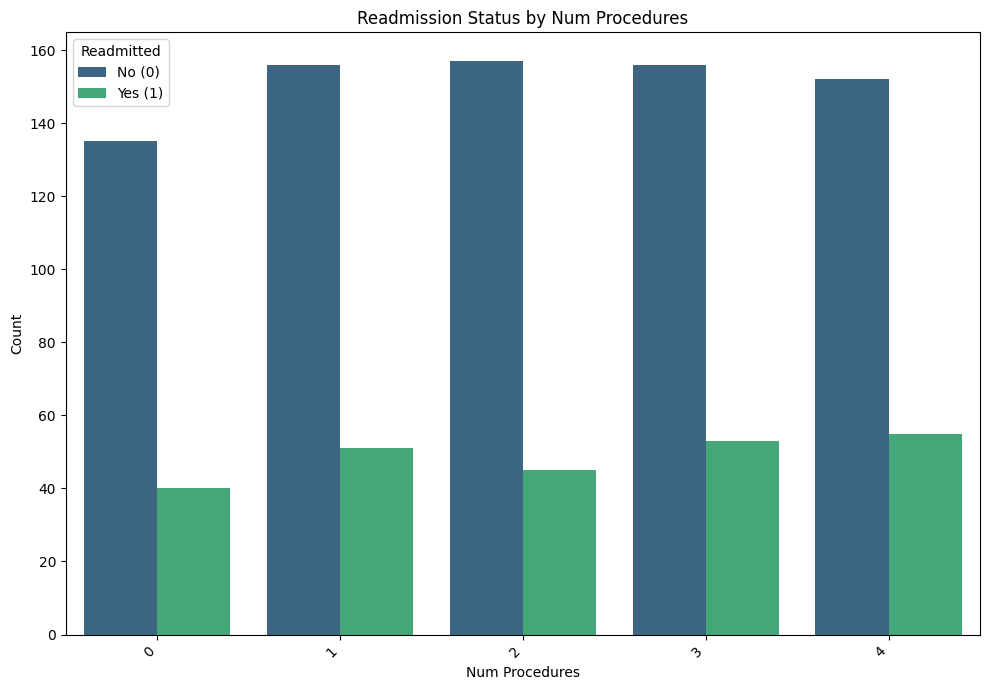

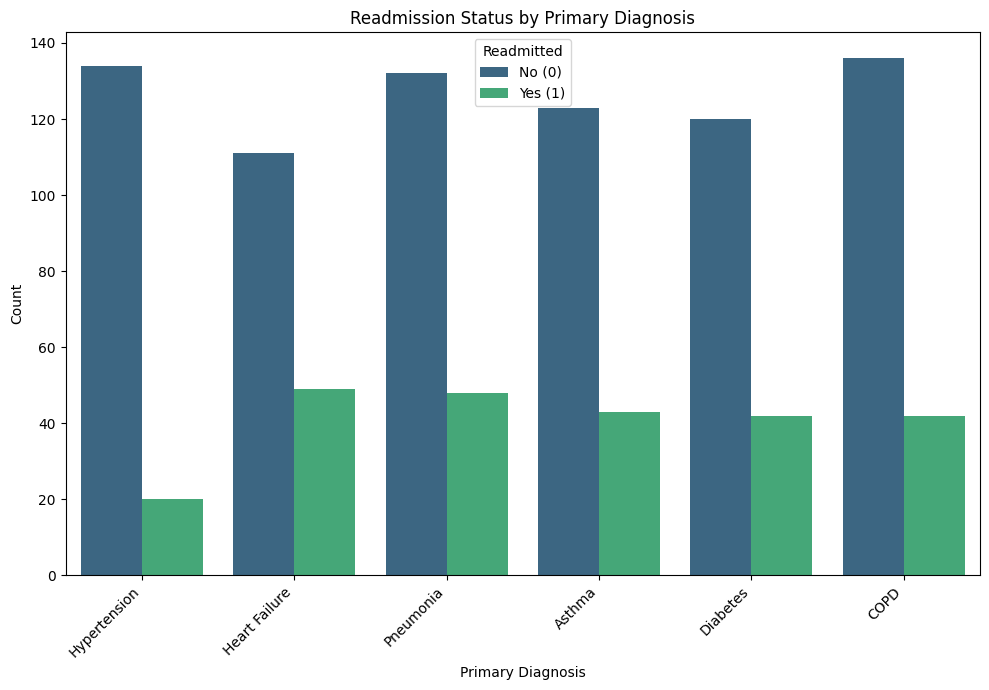

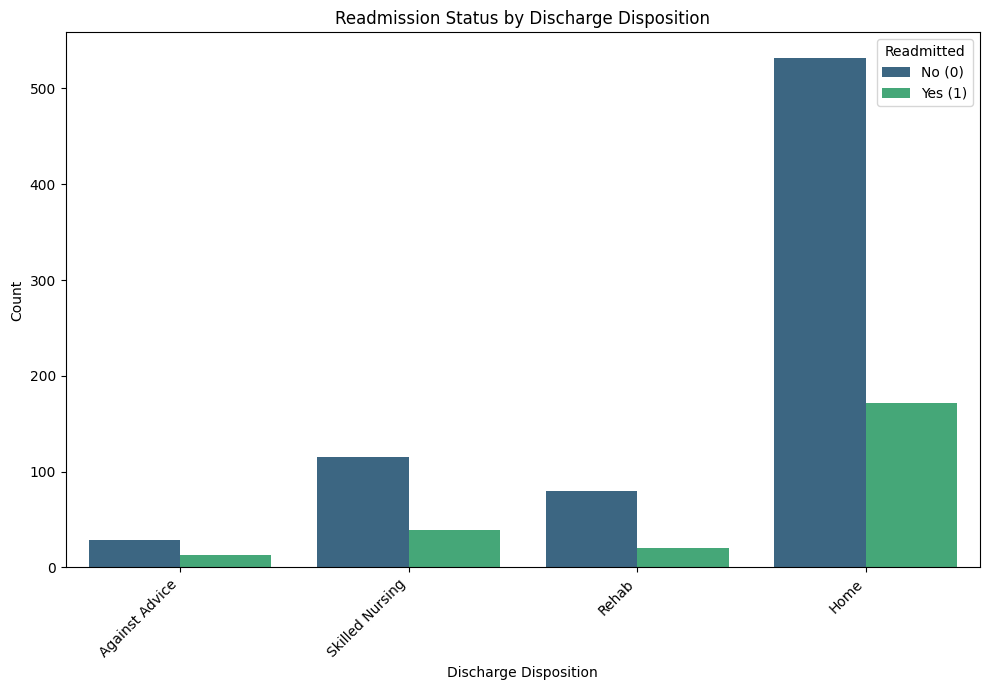

In [5]:
print("Generating count plots for categorical features vs. readmitted status...")
categorical_features_for_analysis = ['gender', 'num_procedures', 'primary_diagnosis', 'discharge_disposition']

for feature in categorical_features_for_analysis:
    plt.figure(figsize=(10, 7))
    sns.countplot(data=df, x=feature, hue='readmitted', palette='viridis')
    plt.title(f'Readmission Status by {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Readmitted', labels=['No (0)', 'Yes (1)'])
    plt.tight_layout()
    plt.show()

## Final Task

### Subtask:
Summarize the key findings from the comprehensive EDA, highlighting important patterns, distributions, and relationships that are relevant to predicting patient readmission.


## Summary:

### Data Analysis Key Findings

*   **Readmission Rate**: Approximately 24.4% of patients in the dataset were readmitted, indicating an imbalanced target variable.
*   **Age Distribution**: Patient ages range broadly from 18 to 89 years, with a mean of 52.88 years, showing a wide age demographic.
*   **Length of Stay**: Hospital stays vary from 1 to 14 days, with an average of 7.5 days.
*   **Medication Usage**: Patients are prescribed between 1 and 19 medications, averaging about 10.13, suggesting varied medical complexities.
*   **Discharge Disposition**: 'Home' is the most common discharge disposition, accounting for 704 out of 1000 patients, significantly more than other options like 'Skilled Nursing' (154), 'Rehab' (100), or 'Against Advice' (42).
*   **Primary Diagnoses**: The six primary diagnoses (Pneumonia, COPD, Asthma, Diabetes, Heart Failure, Hypertension) are relatively evenly distributed across the patient population, each accounting for 15-18% of cases.
*   **Gender Distribution**: The dataset has a relatively balanced gender distribution with 486 females, 472 males, and 42 recorded as 'Other'.
*   **Numerical Features vs. Readmission**:
    *   **Age**: Patients who are readmitted appear to have a slightly higher median age compared to those not readmitted.
    *   **Length of Stay**: Patients with longer lengths of stay tend to have a higher likelihood of readmission.
    *   **Number of Medications**: A higher number of medications prescribed seems to correlate with an increased chance of readmission.
*   **Categorical Features vs. Readmission**:
    *   **Discharge Disposition**: Patients discharged 'Against Advice' show a disproportionately higher rate of readmission compared to other discharge dispositions.
    *   **Primary Diagnosis**: While all diagnoses show readmissions, certain diagnoses might have slightly varied readmission rates, though this requires closer inspection.
    *   **Gender**: Readmission rates appear similar across different genders.
    *   **Number of Procedures**: The number of procedures performed does not show a strong, clear relationship with readmission likelihood, as readmission counts are somewhat proportional across different procedure counts.

### Insights or Next Steps

*   The imbalance in the `readmitted` target variable (24.4% readmitted) should be addressed during model training, possibly using techniques like oversampling, undersampling, or appropriate evaluation metrics (e.g., F1-score, ROC-AUC) that are robust to class imbalance.
*   The strong correlation observed between `length_of_stay`, `num_medications`, and `discharge_disposition` (especially 'Against Advice') with readmission status suggests these features will be highly influential in predicting patient readmission and warrant further investigation and careful feature engineering.
